In [25]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from lime import lime_image
from skimage.segmentation import mark_boundaries

In [26]:
IMG_SIZE = (75, 75)
BATCH_SIZE = 32
LIMIT_PER_CLASS = 100
NUM_CLASSES = 8

model = load_model('emotion_cnn_model.h5')

# 100 photos per class
def get_limited_dataset(root_dir, target_size=(224, 224), limit_per_class=100):
    all_images = []
    all_labels = []
    class_names = sorted(os.listdir(root_dir))

    for label_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(root_dir, class_name)
        image_files = os.listdir(class_dir)
        random.shuffle(image_files)
        selected_files = image_files[:limit_per_class]

        for image_file in selected_files:
            image_path = os.path.join(class_dir, image_file)
            img = load_img(image_path, target_size=target_size)
            img_array = img_to_array(img) / 255.0
            all_images.append(img_array)
            all_labels.append(label_idx)

    return tf.convert_to_tensor(all_images), tf.convert_to_tensor(all_labels), class_names

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step

 Classification Report:

              precision    recall  f1-score   support

       anger       0.98      1.00      0.99       100
    contempt       1.00      1.00      1.00       100
     disgust       0.99      1.00      1.00       100
        fear       1.00      1.00      1.00       100
   happiness       0.94      0.89      0.91       100
     neutral       0.92      0.91      0.91       100
     sadness       0.98      1.00      0.99       100
    surprise       0.99      1.00      1.00       100

    accuracy                           0.97       800
   macro avg       0.97      0.97      0.97       800
weighted avg       0.97      0.97      0.97       800



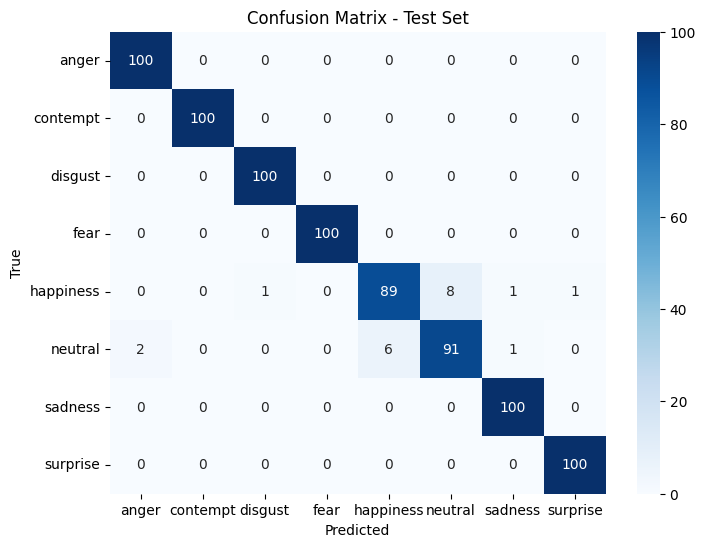

In [27]:
x_test, y_test, class_names = get_limited_dataset(r'C:\Users\48668\Documents\jdszr18-Neuronauci\FER-2013_balanced\test', target_size=IMG_SIZE, limit_per_class=LIMIT_PER_CLASS)

preds = model.predict(x_test)
y_pred = np.argmax(preds, axis=1)
y_true = y_test.numpy()

print("\n Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


confusion_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Test Set")
plt.show()


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


  1%|          | 10/1000 [00:00<00:21, 45.02it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


  2%|▏         | 20/1000 [00:00<00:16, 57.79it/s]

...

 98%|█████████▊| 980/1000 [00:21<00:00, 45.23it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


 99%|█████████▉| 990/1000 [00:21<00:00, 46.93it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


100%|██████████| 1000/1000 [00:22<00:00, 45.19it/s]


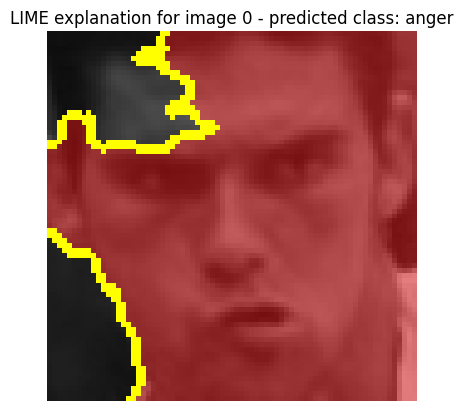

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


  1%|          | 10/1000 [00:00<00:25, 38.94it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


  2%|▏         | 20/1000 [00:00<00:21, 45.40it/s]

...

 98%|█████████▊| 980/1000 [00:21<00:00, 45.05it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


 99%|█████████▉| 990/1000 [00:21<00:00, 46.51it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


100%|██████████| 1000/1000 [00:21<00:00, 45.54it/s]


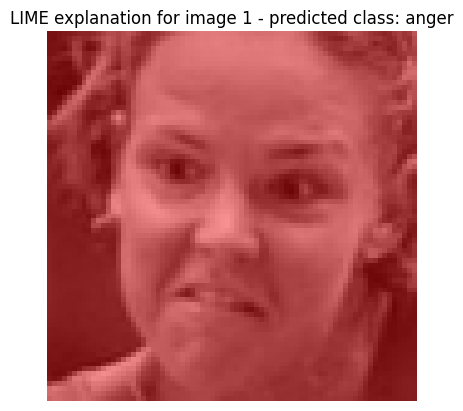

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


  1%|          | 10/1000 [00:00<00:18, 53.77it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


  2%|▏         | 20/1000 [00:00<00:18, 54.14it/s]

...

 98%|█████████▊| 980/1000 [00:18<00:00, 48.08it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


 99%|█████████▉| 990/1000 [00:18<00:00, 45.79it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


100%|██████████| 1000/1000 [00:19<00:00, 52.04it/s]


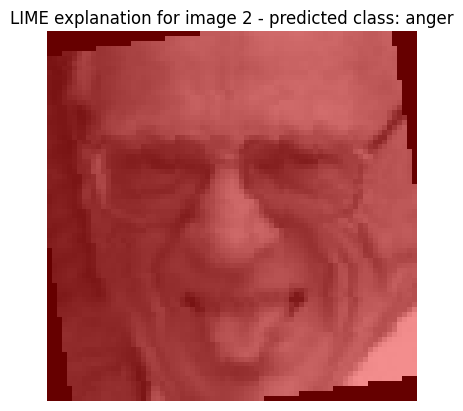

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


  1%|          | 10/1000 [00:00<00:20, 49.35it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


  2%|▏         | 20/1000 [00:00<00:20, 48.74it/s]

...

 98%|█████████▊| 980/1000 [00:24<00:00, 26.04it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


 99%|█████████▉| 990/1000 [00:24<00:00, 28.53it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


100%|██████████| 1000/1000 [00:24<00:00, 40.16it/s]


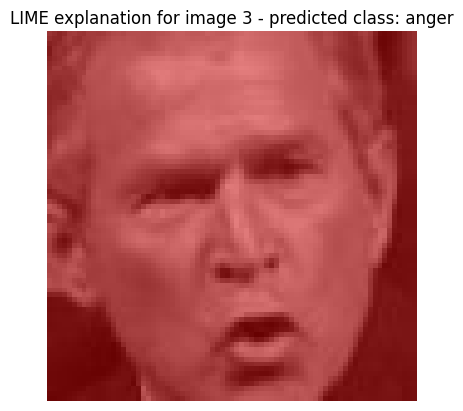

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


  1%|          | 10/1000 [00:00<00:27, 36.40it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


  2%|▏         | 20/1000 [00:00<00:27, 36.17it/s]

...

 98%|█████████▊| 980/1000 [00:21<00:00, 42.02it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


 99%|█████████▉| 990/1000 [00:21<00:00, 43.91it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step


100%|██████████| 1000/1000 [00:21<00:00, 45.78it/s]


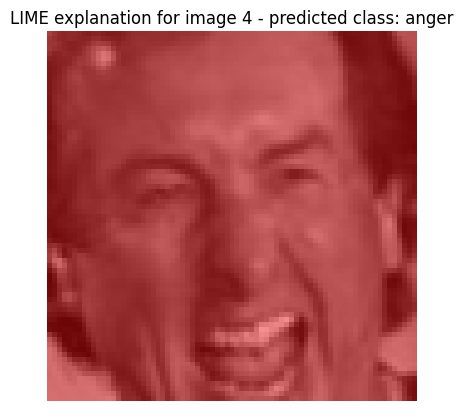

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


  1%|          | 10/1000 [00:00<00:21, 46.90it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


  2%|▏         | 20/1000 [00:00<00:22, 43.76it/s]

...

 98%|█████████▊| 980/1000 [00:19<00:00, 63.51it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


 99%|█████████▉| 990/1000 [00:19<00:00, 64.59it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


100%|██████████| 1000/1000 [00:19<00:00, 50.56it/s]


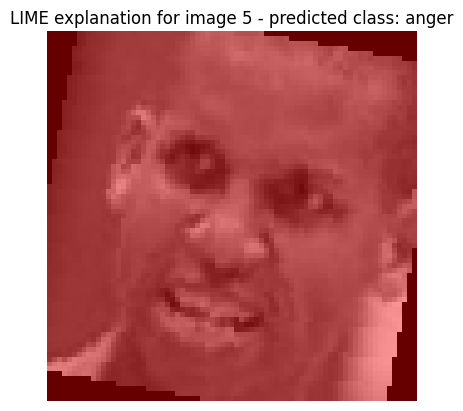

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step


  1%|          | 10/1000 [00:00<00:34, 28.37it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step


  2%|▏         | 20/1000 [00:00<00:38, 25.52it/s]

...

 98%|█████████▊| 980/1000 [00:20<00:00, 44.92it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


 99%|█████████▉| 990/1000 [00:21<00:00, 43.39it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


100%|██████████| 1000/1000 [00:21<00:00, 47.00it/s]


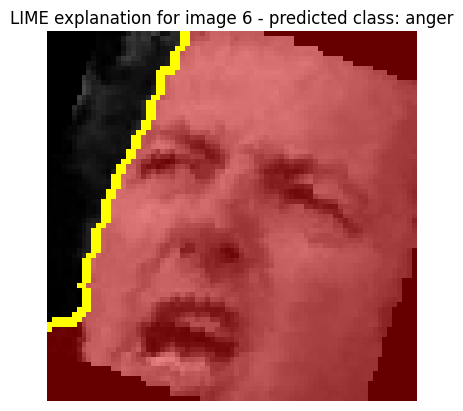

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


  1%|          | 10/1000 [00:00<00:14, 69.49it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


  2%|▏         | 20/1000 [00:00<00:17, 57.36it/s]

...

 98%|█████████▊| 980/1000 [00:26<00:00, 30.61it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step


 99%|█████████▉| 990/1000 [00:27<00:00, 27.78it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step


100%|██████████| 1000/1000 [00:27<00:00, 36.29it/s]


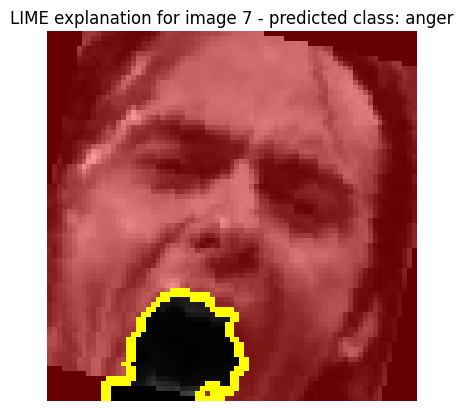

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step


  1%|          | 10/1000 [00:00<00:41, 23.80it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step


  2%|▏         | 20/1000 [00:00<00:42, 23.10it/s]

...

 98%|█████████▊| 980/1000 [00:25<00:00, 33.41it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


 99%|█████████▉| 990/1000 [00:25<00:00, 37.80it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step


100%|██████████| 1000/1000 [00:26<00:00, 38.29it/s]


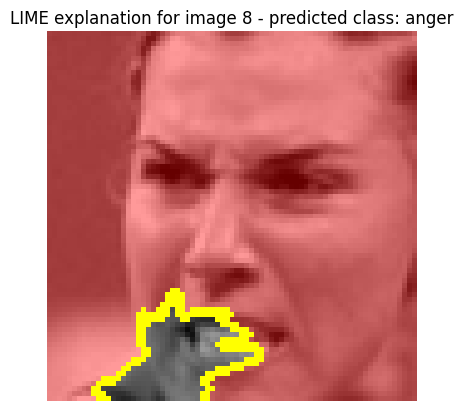

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


  1%|          | 10/1000 [00:00<00:24, 40.32it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


  2%|▏         | 20/1000 [00:00<00:24, 40.38it/s]

...

 98%|█████████▊| 980/1000 [00:25<00:00, 47.61it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


 99%|█████████▉| 990/1000 [00:25<00:00, 51.40it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


100%|██████████| 1000/1000 [00:25<00:00, 38.76it/s]


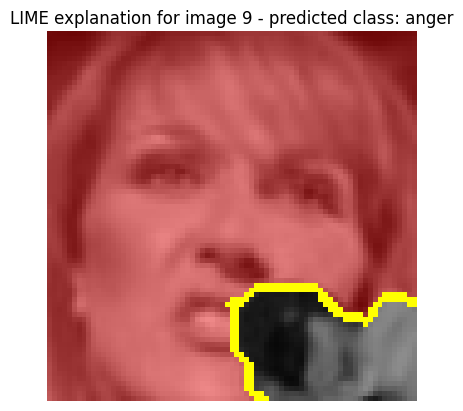

In [32]:
# LIME:
explainer = lime_image.LimeImageExplainer()

sample_indices = list(range(10))
for idx in sample_indices:
    image_np = x_test[idx].numpy()
    image_batch = np.expand_dims(image_np, axis=0)

    explanation = explainer.explain_instance(
        image_np.astype('double'),
        classifier_fn=lambda x: model.predict(x),
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=15,
        hide_rest=False
    )
    # plt.figure()
    # plt.imshow(image_np)
    # plt.imshow(mask, alpha=0.3, cmap='Reds')
    # plt.title(f"LIME explanation for image {idx} - predicted class: {class_names[y_pred[idx]]}")
    # plt.axis('off')
    # plt.show()
    original_image = image_np / 255.0 if image_np.max() > 1 else image_np
    # Create colored mask overlay
    colored_mask = np.zeros_like(original_image)
    colored_mask[mask > 0] = [1, 0, 0]  # Red color for important regions
    # Combine original image with semi-transparent mask
    alpha = 0.4  # Transparency level
    overlay_image = original_image * (1 - alpha) + colored_mask * alpha
    # Add boundaries for better visualization
    final_image = mark_boundaries(overlay_image, mask, color=(1, 1, 0), mode='thick')
    plt.figure()
    plt.imshow(final_image)
    plt.title(f"LIME explanation for image {idx} - predicted class: {class_names[y_pred[idx]]}")
    plt.axis('off')
    plt.show()
